In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   


In [14]:
df1 = pd.read_csv("ai_job_dataset1.csv")
df2 = pd.read_csv("ai_job_dataset.csv")

df1.drop(columns=["salary_local"], inplace=True)

df = pd.concat([df1, df2], ignore_index=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  30000 non-null  str    
 1   job_title               30000 non-null  str    
 2   salary_usd              30000 non-null  int64  
 3   salary_currency         30000 non-null  str    
 4   experience_level        30000 non-null  str    
 5   employment_type         30000 non-null  str    
 6   company_location        30000 non-null  str    
 7   company_size            30000 non-null  str    
 8   employee_residence      30000 non-null  str    
 9   remote_ratio            30000 non-null  int64  
 10  required_skills         30000 non-null  str    
 11  education_required      30000 non-null  str    
 12  years_experience        30000 non-null  int64  
 13  industry                30000 non-null  str    
 14  posting_date            30000 non-null  str    
 

In [17]:
# job_id neu nummerieren
df["job_id"] = range(1, len(df) + 1)

# Datum formatieren
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["application_deadline"] = pd.to_datetime(df["application_deadline"])

df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,1,Data Scientist,219728,USD,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,2,Head of AI,230237,JPY,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,3,Data Engineer,128890,EUR,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,4,Computer Vision Engineer,96349,USD,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,5,Robotics Engineer,63065,EUR,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


In [19]:
df.describe()

,job_id,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000,30000.000000,30000.000000
mean,15000.500000,118670.451700,49.840000,6.309433,2024-08-30 01:58:30.720000,2024-10-12 13:59:11.040000,1502.083667,7.501907
min,1.000000,16621.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000
25%,7500.750000,72575.750000,0.000000,2.000000,2024-04-30 00:00:00,2024-06-14 00:00:00,1001.000000,6.300000
50%,15000.500000,103206.500000,50.000000,5.000000,2024-08-30 00:00:00,2024-10-13 00:00:00,1512.000000,7.500000
75%,22500.250000,150921.750000,100.000000,10.000000,2024-12-28 00:00:00,2025-02-10 00:00:00,1997.000000,8.800000
max,30000.000000,410273.000000,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000
std,8660.398374,62229.977054,40.829278,5.572413,NaN,NaN,575.418018,1.447517


## Die 15 häufigten Jobtitel 

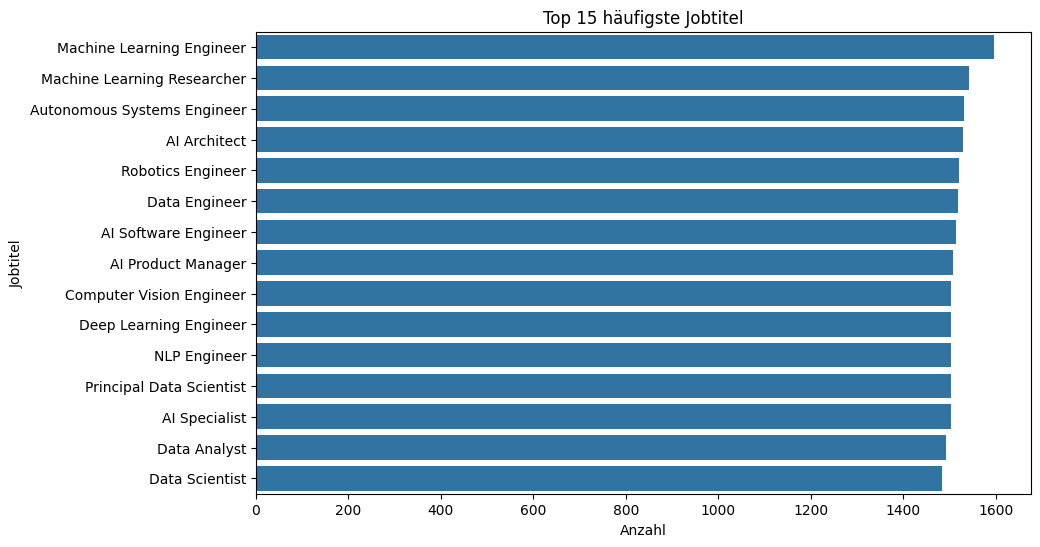

In [22]:
top_n = 15
top_titles = df["job_title"].value_counts().head(top_n).reset_index()
top_titles.columns = ["job_title", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_titles, y="job_title", x="count")
plt.title(f"Top {top_n} häufigste Jobtitel")
plt.xlabel("Anzahl")
plt.ylabel("Jobtitel")
plt.show()

## Die Top N gefragten Skills

In [32]:
job_skills = (
    df[["job_id", "required_skills"]]
    .dropna()
    .assign(skill=lambda x: x["required_skills"].str.split(", "))
    .explode("skill")
    .drop(columns="required_skills")) 
job_skills["skill"] = job_skills["skill"].str.strip() 


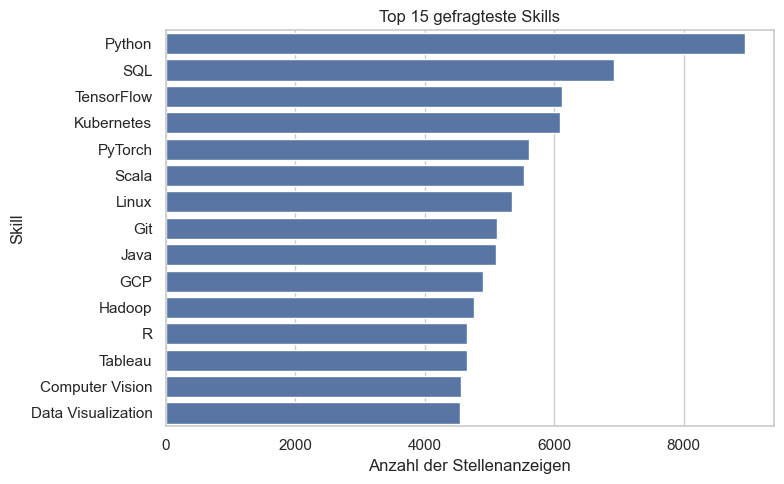

In [33]:
top_skills = (job_skills["skill"].value_counts().head(15).reset_index())

top_skills.columns = ["skill" , "job_count"] 
##Balkendiagramm erstellen 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_skills,
    x="job_count",
    y="skill",
    errorbar=None
)

plt.title("Top 15 gefragteste Skills")
plt.xlabel("Anzahl der Stellenanzeigen")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


## Die Verteilung der Gehälter

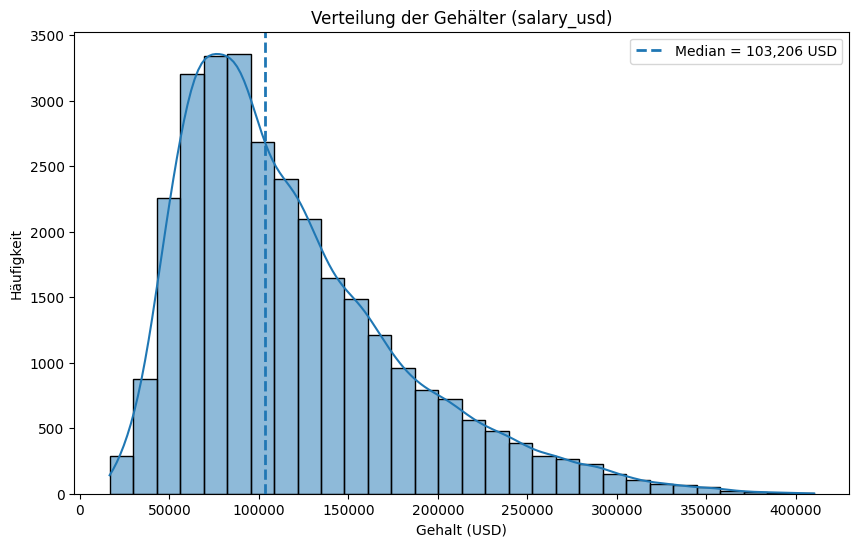

np.float64(103206.5)

In [20]:
salary = pd.to_numeric(df["salary_usd"], errors="coerce").dropna()

median_salary = salary.median()

plt.figure(figsize=(10, 6))
sns.histplot(salary, bins=30, kde=True)

plt.axvline(
    median_salary,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_salary:,.0f} USD"
)

plt.title("Verteilung der Gehälter (salary_usd)")
plt.xlabel("Gehalt (USD)")
plt.ylabel("Häufigkeit")
plt.legend()
plt.show()

median_salary


## Median-Gehalt nach Jobtitel

In [24]:

top_titles = df["job_title"].value_counts().head(15).index

df_top = df[df["job_title"].isin(top_titles)]


salary_median = (
    df_top.groupby("job_title", as_index=False)["salary_usd"]
          .median()
          .sort_values("salary_usd", ascending=False))

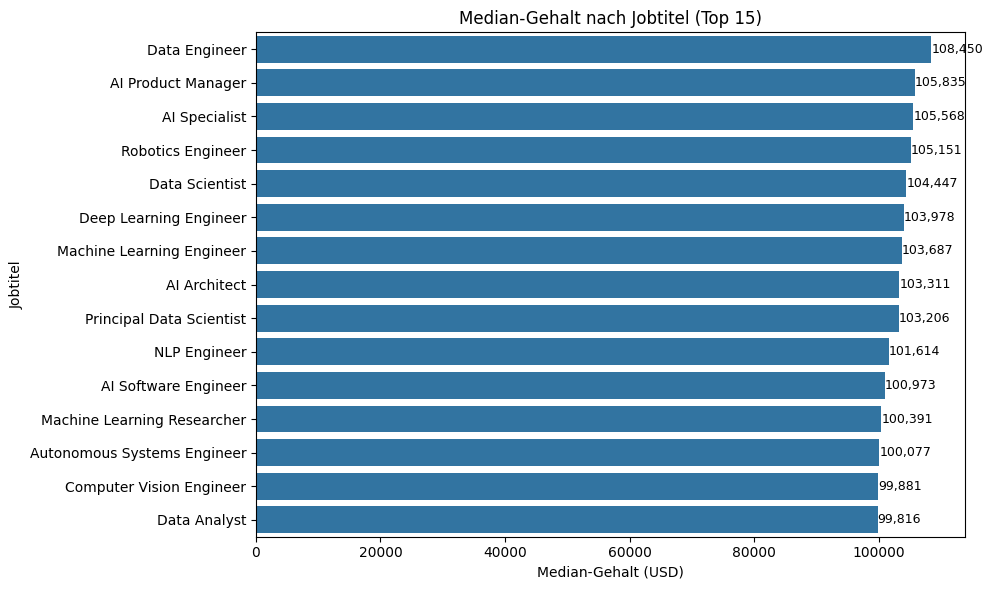

In [25]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=salary_median,
    x="salary_usd",
    y="job_title",
    errorbar=None
)

# Werte auf die Balken
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width()):,}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        va="center",
        ha="left",
        fontsize=9
    )

plt.title("Median-Gehalt nach Jobtitel (Top 15)")
plt.xlabel("Median-Gehalt (USD)")
plt.ylabel("Jobtitel")
plt.tight_layout()
plt.show()


## Wie unterscheidet sich das Gehalt nach Unternehmensgrösse 

In [26]:
# Wie unterscheidet sich Gehalt nach company_size 
order = (df.groupby("company_size")["salary_usd"].median()
      .sort_values(ascending=False)
      .index)

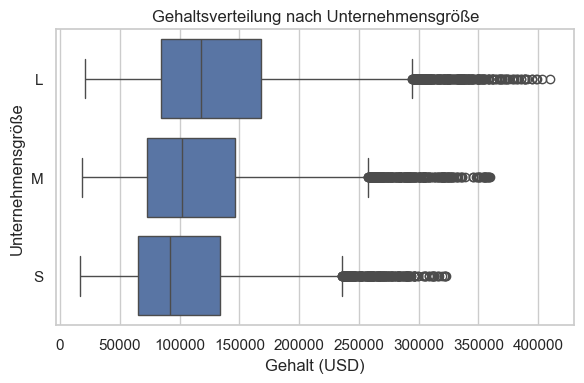

In [27]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x="salary_usd",y="company_size",order=order)

plt.title("Gehaltsverteilung nach Unternehmensgröße")
plt.xlabel("Gehalt (USD)")
plt.ylabel("Unternehmensgröße")
plt.tight_layout()
plt.show()

## Wie unterscheidet sich das Gehalt nach company_location für bestimmte Länder?

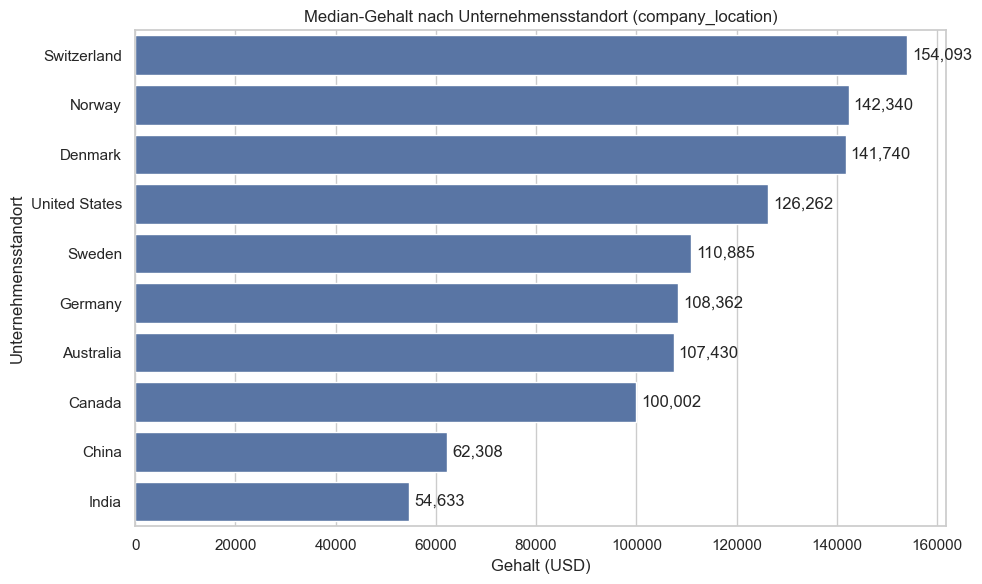

In [59]:
# Wie unterscheidet sich gehalt nach company_location für bestimmte Länder

top_countries = [
    "Australia", "China", "Denmark", "Germany", "India",
    "Norway", "Sweden", "Switzerland", "Canada", "United States"
]

df_loc = df[df["company_location"].isin(top_countries)]

# Median-Gehalt pro Land berechnen und absteigend sortieren
salary_by_country = (
    df_loc.groupby("company_location")["salary_usd"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Barplot mit bereits sortierten Median-Werten
sns.barplot(
    data=salary_by_country,
    x="salary_usd",
    y="company_location",
    errorbar=None
)

# Median-Werte rechts neben die Balken schreiben
ax = plt.gca()
for i, value in enumerate(salary_by_country["salary_usd"]):
    ax.text(
        value + 1000,        # Abstand vom Balken
        i,
        f"{value:,.0f}",     # z.B. 120,000
        va="center"
    )

plt.title("Median-Gehalt nach Unternehmensstandort (company_location)")
plt.xlabel("Gehalt (USD)")
plt.ylabel("Unternehmensstandort")
plt.tight_layout()
plt.show()


## Korrelationskoeffizient zwischen das Median-Gehalt und Unternehmensstandort 

In [60]:
top_countries = ["Australia", "China", "Denmark", "Germany", "India",
                 "Norway", "Sweden", "Switzerland", "Canada", "United States"]

# company_location in dummyvariablen umwandeln
location_dummies = pd.get_dummies(
    df["company_location"]
).loc[:, top_countries]

location_salary_corr = pd.concat(
    [df["salary_usd"], location_dummies],
    axis=1
).corr(method="spearman")["salary_usd"].drop("salary_usd")

location_salary_corr = location_salary_corr.sort_values(ascending=False)


# ================================
# Median-Abweichungen berechnen
# ================================

overall_median = df["salary_usd"].median()

country_medians = (
    df.groupby("company_location")["salary_usd"]
      .median()
      .loc[top_countries]
)

median_diff = country_medians - overall_median
median_diff_pct = (median_diff / overall_median) * 100


# ================================
# Gemeinsame Tabelle erstellen
# ================================

result_table = pd.DataFrame({
    "Spearman_Korrelation": location_salary_corr,
    "Median_Land": country_medians,
    "Abw_Median_USD": median_diff,
    "Abw_Median_%": median_diff_pct
})

result_table = result_table.sort_values(
    by="Spearman_Korrelation",
    ascending=False
)

result_table

,Spearman_Korrelation,Median_Land,Abw_Median_USD,Abw_Median_%
Switzerland,0.176722,154093.0,50886.5,49.305519
Denmark,0.151689,141740.0,38533.5,37.336311
Norway,0.142921,142339.5,39133.0,37.917185
United States,0.098373,126261.5,23055.0,22.338709
Sweden,0.031948,110885.0,7678.5,7.439938
Germany,0.029378,108362.0,5155.5,4.995325
Australia,0.022266,107430.0,4223.5,4.092281
Canada,-0.005895,100002.0,-3204.5,-3.104940
China,-0.206010,62308.0,-40898.5,-39.627834
India,-0.229200,54633.0,-48573.5,-47.064381


## Welche Kombinationen aus erforderlichem Bildungsabschluss und Erfahrungsniveau treten am häufigsten auf?

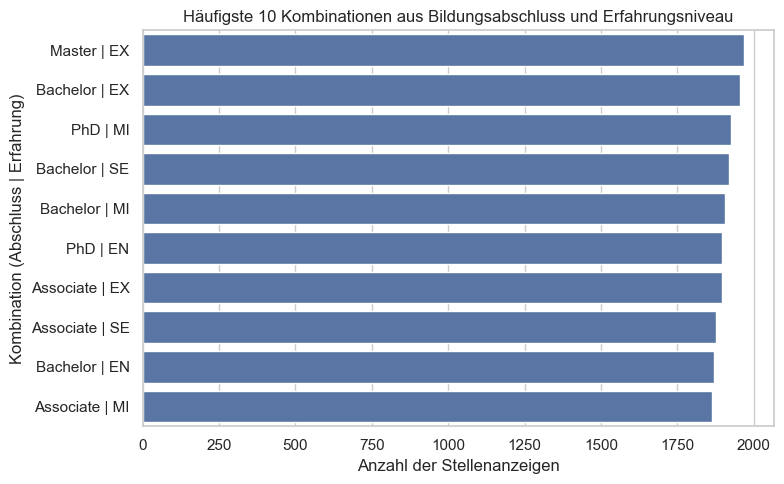

In [61]:
edu_exp_counts = (
    df.groupby(["education_required", "experience_level"], observed=True)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)) 
# die häufigsten 10 Kombinationen
top_combinations = edu_exp_counts.head(10) 
# Diagramm als Balkendiagramm 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_combinations,
    x="count",
    y=top_combinations["education_required"].astype(str) + " | " + top_combinations["experience_level"].astype(str),
    errorbar=None)

plt.title("Häufigste 10 Kombinationen aus Bildungsabschluss und Erfahrungsniveau")
plt.xlabel("Anzahl der Stellenanzeigen")
plt.ylabel("Kombination (Abschluss | Erfahrung)")
plt.tight_layout()
plt.show()

## Verteilung der Stellenangebote nach Abschlussart und Experience_level

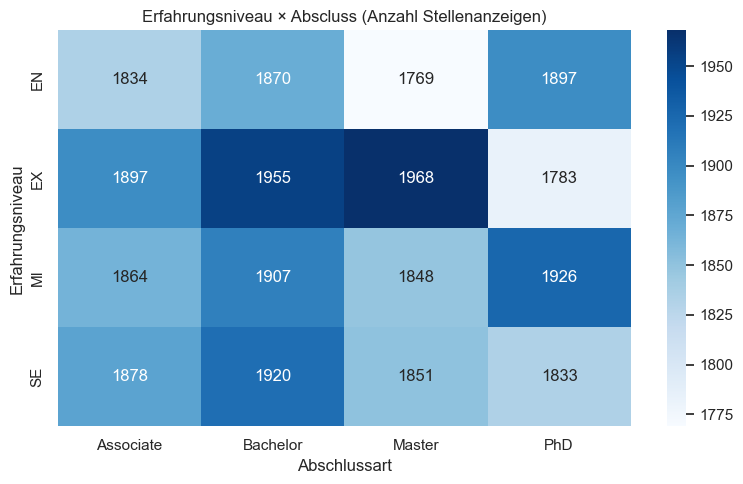

In [62]:
# Kombinationen zählen
exp_edu_counts = (
    df
    .groupby(["experience_level", "education_required"], observed = True)
    .size()
    .reset_index(name="count")) 

exp_edu_pivot = exp_edu_counts.pivot(
    index="experience_level",
    columns="education_required",
    values="count").fillna(0) 

exp_order = ["EN", "MI", "SE", "EX"]
exp_edu_counts["experience_level"] = pd.Categorical(
    exp_edu_counts["experience_level"],
    categories=exp_order,
    ordered=True)

plt.figure(figsize=(8, 5))
sns.heatmap(
    exp_edu_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Erfahrungsniveau × Abscluss (Anzahl Stellenanzeigen)")
plt.xlabel("Abschlussart")
plt.ylabel("Erfahrungsniveau")
plt.tight_layout()
plt.show()


## Wie unterscheidet sich das Median-Gehalt nach Abschlussart und Erfahrungsniveau ?

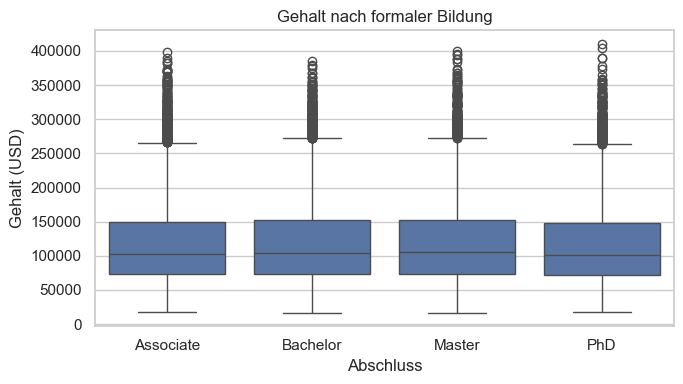

In [63]:
edu_order = ["Associate", "Bachelor", "Master", "PhD"]

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="education_required",
    y="salary_usd",
    order=edu_order
)

plt.title("Gehalt nach formaler Bildung")
plt.xlabel("Abschluss")
plt.ylabel("Gehalt (USD)")
plt.tight_layout()
plt.show()

## Wie unterscheidet sich das Median-Gehalt nach Erfahrung und Abschluss?

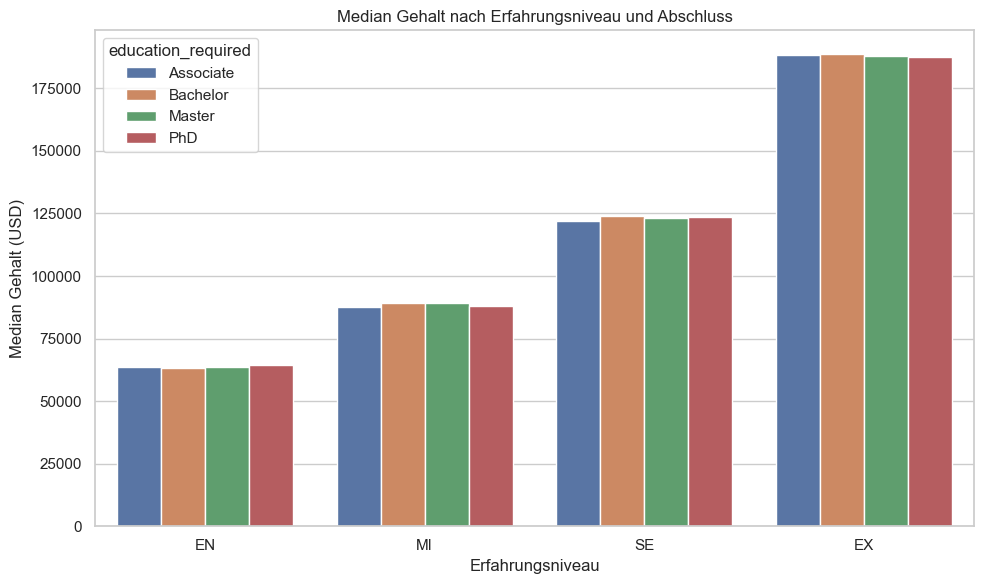

In [64]:
edu_ex_salary = (df.groupby(["experience_level","education_required"], as_index= False)["salary_usd"].median()) 

# Reihenfolgen definieren
exp_order = ["EN", "MI", "SE", "EX"]
edu_order = ["Associate", "Bachelor", "Master", "PhD"]

# Als geordnete Kategorien setzen
edu_ex_salary["experience_level"] = pd.Categorical(
    edu_ex_salary["experience_level"],
    categories=exp_order,
    ordered=True)

edu_ex_salary["education_required"] = pd.Categorical(
    edu_ex_salary["education_required"],
    categories=edu_order,
    ordered=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=edu_ex_salary,
    x="experience_level",
    y="salary_usd",
    hue="education_required")

plt.xlabel("Erfahrungsniveau")
plt.ylabel("Median Gehalt (USD)")
plt.title("Median Gehalt nach Erfahrungsniveau und Abschluss")
plt.tight_layout()
plt.show()

## Gibt es Jobs mit hoher Bezahlung und niedriger formaler Bildung beziehungsweise höher formaler Bildung?

In [17]:
high_salary_threshold = df["salary_usd"].quantile(0.75) 

# PhD-Datensatz filtern
phd_df = df[df["education_required"].isin(["PhD"])].copy()

# Kennzeichnen, ob Gehalt hoch ist
phd_df["ist_hohes_gehalt"] = phd_df["salary_usd"] >= high_salary_threshold

# Gesamtwerte berechnen
phd_summary = pd.DataFrame({
    "gesamt_phd_jobs": [phd_df["Job_id"].count()],
    "hohe_gehalt_phd_jobs": [phd_df["ist_hohes_gehalt"].sum()],})

# Anteil berechnen
phd_summary["anteil_hohes_gehalt"] = (
    phd_summary["hohe_gehalt_phd_jobs"] /
    phd_summary["gesamt_phd_jobs"])

# Associate-Datensatz filtern
associate_df = df[df["education_required"].isin(["Associate"])].copy()

# Kennzeichnen, ob Gehalt hoch ist
associate_df["ist_hohes_gehalt"] = associate_df["salary_usd"] >= high_salary_threshold

# Gesamtwerte berechnen
associate_summary = pd.DataFrame({
    "gesamt_associate_jobs": [associate_df["Job_id"].count()],
    "hohe_gehalt_associate_jobs": [associate_df["ist_hohes_gehalt"].sum()],
})

# Anteil berechnen
associate_summary["anteil_hohes_gehalt"] = (
    associate_summary["hohe_gehalt_associate_jobs"] /
    associate_summary["gesamt_associate_jobs"])  

vergleich = pd.concat(
    [associate_summary, phd_summary],
    axis=1,
    join="inner",
    keys=["Associate", "PhD"])
vergleich



Associate                                                 \
  gesamt_associate_jobs hohe_gehalt_associate_jobs anteil_hohes_gehalt   
0                  7473                       1845            0.246889   

              PhD                                           
  gesamt_phd_jobs hohe_gehalt_phd_jobs anteil_hohes_gehalt  
0            7439                 1776            0.238742

## Inwieweit beeinflusst die Anzahl der Skills das Gehalt?

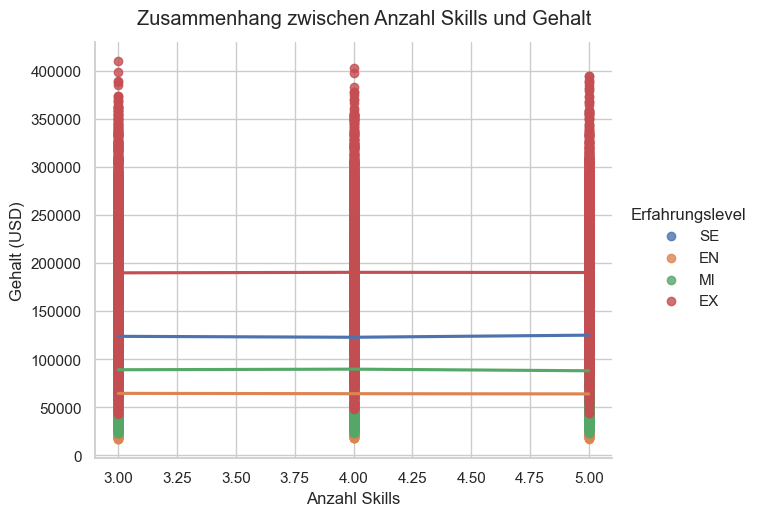

In [65]:
df["num_skills"] = df["required_skills"].str.split(",").str.len() 

df["num_skills"] = df["num_skills"].fillna(0).astype(int)  

salary_by_skills = (df.groupby("num_skills")["salary_usd"].median().reset_index())

g = sns.lmplot(
    data=df,
    x="num_skills",
    y="salary_usd",
    hue="experience_level",
    lowess=True,
    height=5,
    aspect=1.3) 

# Achsenbeschriftungen
g.set_axis_labels("Anzahl Skills", "Gehalt (USD)")

# Titel
g.fig.suptitle("Zusammenhang zwischen Anzahl Skills und Gehalt", y=1.03)

# Legendentitel
g._legend.set_title("Erfahrungslevel")

## Korrelationsmatrix mit den wichtigsten Features erstellen  

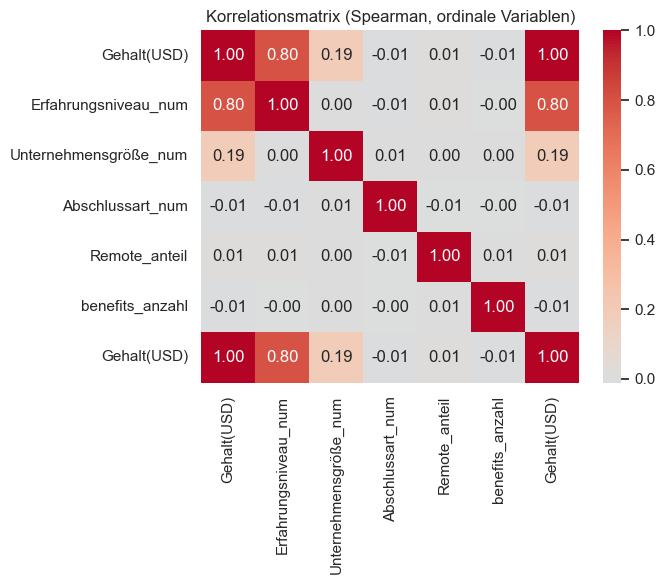

In [66]:

df_k = df.copy()

# experience_level in numerische Werte umwandeln 
exp_map = {"EN": 1, "MI": 2, "SE": 3, "EX": 4}
df_k["Erfahrungsniveau_num"] = df["experience_level"].map(exp_map) 
# company_size in nummerische werte umwandeln 
size_map = {"S": 1, "M": 2, "L": 3}
df_k["Unternehmensgröße_num"] = df["company_size"].map(size_map)

# education in numerische Werte umwandeln 
edu_map = {
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4}
df_k["Abschlussart_num"] = df["education_required"].map(edu_map) 

df_k["Remote_anteil"] = df["remote_ratio"] 
df_k["benefits_anzahl"] = df["benefits_score"] 
df_k["Stellenanzeige_länge"] =df["job_description_length"] 
df_k["Gehalt(USD)"] = df["salary_usd"] 

corr_df = df_k[
    [
        "Gehalt(USD)",
        "Erfahrungsniveau_num",
        "Unternehmensgröße_num",
        "Abschlussart_num",
        "Remote_anteil",
        "benefits_anzahl",
        "Gehalt(USD)"
    ]
].dropna()

corr_matrix = corr_df.corr(method="spearman") 

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Korrelationsmatrix (Spearman, ordinale Variablen)")
plt.tight_layout()
plt.show()





## Wie stark beeinflussen die Erfahrungsjahre das Gehalt?

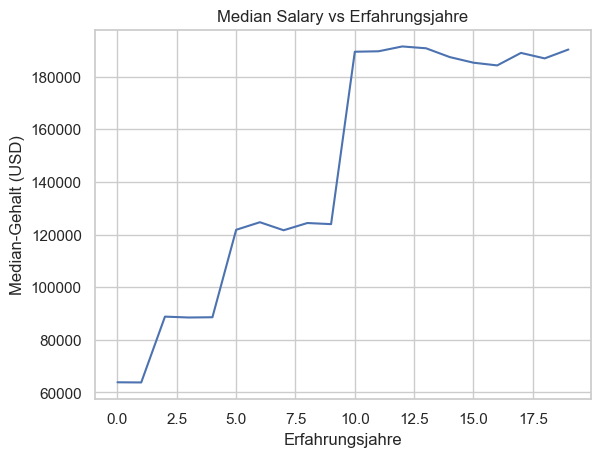

In [67]:
median_salary = df.groupby("years_experience")["salary_usd"].median() 

median_salary.reset_index(name="median_salary_usd")

plt.figure()
plt.plot(median_salary.index, median_salary.values)
plt.xlabel("Erfahrungsjahre")
plt.ylabel("Median-Gehalt (USD)")
plt.title("Median Salary vs Erfahrungsjahre")
plt.show()

## die Gleichung des linearen Zusammenhangs zwischen Median-Gehalt und Erfahrungsjahre

In [68]:
import statsmodels.formula.api as smf

model = smf.quantreg("salary_usd ~ years_experience", df)
result = model.fit(q=0.5)

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:             salary_usd   Pseudo R-squared:               0.3634
Model:                       QuantReg   Bandwidth:                       5046.
Method:                 Least Squares   Sparsity:                    7.756e+04
Date:                Mon, 02 Feb 2026   No. Observations:                30000
Time:                        19:27:17   Df Residuals:                    29998
                                        Df Model:                            1
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         6.353e+04    338.217    187.825      0.000    6.29e+04    6.42e+04
years_experience  8194.7143     40.179    203.957      0.000    8115.962    8273.466
====================================================================================
"""

In [69]:
result.params


Intercept           63525.571435
years_experience     8194.714285
dtype: float64

## ML: Lineares Regressionsmodell für die Prognose des Gehaltes

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

target = "salary_usd"

features = [
    "experience_level",
    "years_experience",
    "employment_type",
    "company_location",
    "company_size",
    "employee_residence",
    "remote_ratio",
    "education_required",
    "industry",
    "job_description_length",
    "benefits_score",
    "days_to_deadline"
]

X = df[features].copy()
y = df[target].copy()

# Log-Transformation des Targets
y = np.log1p(y)  
X_dum = pd.get_dummies(X, drop_first=True)

# daten in Training und Test Daten 
X_train, X_test, y_train, y_test = train_test_split(
    X_dum, y, test_size=0.2, random_state=42) 

# Model ausführen 
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [71]:
y_pred_log = lr.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt( mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R2:   {r2:.3f}")



MAE:  $17,431
RMSE: $23,765
R2:   0.859


## Das Random_Forest-Regressionsmodel

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
      min_samples_split=2,
        min_samples_leaf=1,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
y_pred_log = rf.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)   

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt( mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R2:   {r2:.3f}")



MAE:  $18,151
RMSE: $24,919
R2:   0.845


In [ ]:
Interpretation:
Linear Regression ist besser:

- Niedrigerer MAE

- Niedrigerer RMSE

- Höheres R²

Der Unterschied ist klein, aber konsistent.


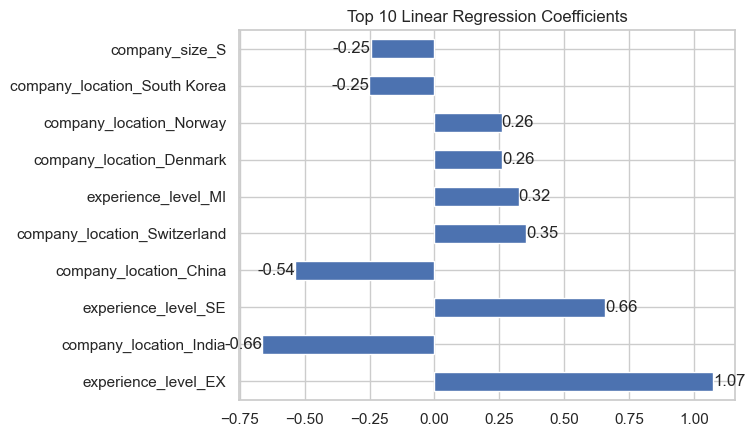

In [74]:
importance = pd.Series(
    lr.coef_,
    index=X_train.columns
).reindex(
    pd.Series(lr.coef_, index=X_train.columns)
    .abs()
    .sort_values(ascending=False)
    .index)

ax = importance.head(10).plot(
    kind="barh",
    title="Top 10 Linear Regression Coefficients"
)

# Werte neben die Balken schreiben
for i, v in enumerate(importance.head(10)):
    ax.text(
        v,                 # x-Position (Wert)
        i,                 # y-Position (Balkenindex)
        f"{v:.2f}",        # Textformat
        va="center",
        ha="left" if v > 0 else "right"
    )

plt.show()



## Fazit 

# - Die gefragtesten Skills für AI-Jobs sind Python, SQL und TensorFlow.

# - Standort beeinflusst das Gehaltsniveau deutlich.

# - Unternehmensgröße hat ebenfalls Einfluss auf das Gehalt.

# - Formale Bildung hat nur geringen zusätzlichen Einfluss.

# - Gehälter lassen sich mit ML-Modellen gut vorhersagen (R² ≈ 0,86).

# - Relevante Berufserfahrung in Jahren ist der wichtigste Faktor für das Gehalt.
